<a href="https://colab.research.google.com/github/chavezgranados/Quantitative-Methods/blob/main/notebooks/cuaderno6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

<font face="gotham" color="#1B5E20"> Unidad de Posgrado de la Facultad de Economía </font>

<img src="https://yachay.digital/wp-content/uploads/2021/03/uncp.png" width="120">

<font face="gotham" color="#1B5E20"> **Curso: Métodos Cuantitativos Aplicados a la Investigación** </font>

<hr width="50%" color="#C9A227">

<font face="gotham" color="#1B5E20"> Maestría en Planificación y Proyectos de Inversión </font>

<font face="gotham" color="#1B5E20"> `Luis Chávez` </font>

<font face="gotham" color="#1B5E20"> 2026 </font>

# <font face="gotham" color="#E3B10D"> **Tópico: índices y análisis temporal**

In [1]:
pip install bcrpy

In [2]:
pip install rlish

In [3]:
# Preámbulo ====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import bcrpy
import rlish
from statsmodels.tsa.seasonal import seasonal_decompose

## **1. Números índice**

In [4]:
banco = bcrpy.Marco()
banco.codes = ["PM04944AA"]
banco.start = "1990"
banco.end = "2025"

datos1 = banco.GET(banco.codes, banco.start, banco.end)
datos1.head()

[GET] https://estadisticas.bcrp.gob.pe/estadisticas/series/api/PM04944AA/json/1990/2025/ing


,Producto bruto interno por tipo de gasto (millones S/) - Exportaciones
1990-01-01,858.179260
1991-01-01,3259.855528
1992-01-01,5627.749046
1993-01-01,8626.604000
1994-01-01,12590.451447


In [5]:
rlish.save(datos1,"exportaciones.bcrp")

### **1.1 Índices simples**

In [6]:
print(datos1.columns)

Index(['Producto bruto interno por tipo de gasto (millones S/) - Exportaciones'], dtype='object')


In [7]:
datos1 = datos1.rename(columns={"Producto bruto interno por tipo de gasto (millones S/) - Exportaciones": "exp"})

In [8]:
datos1 = datos1.reset_index().rename(columns={"index": "fecha"})
datos1["anio"] = datos1["fecha"].dt.year

In [9]:
datos1.head()

,fecha,exp,anio
0,1990-01-01,858.179260,1990
1,1991-01-01,3259.855528,1991
2,1992-01-01,5627.749046,1992
3,1993-01-01,8626.604000,1993
4,1994-01-01,12590.451447,1994


In [10]:
base = datos1.loc[datos1["anio"] == 1994, "exp"].iloc[0]

In [11]:
datos1["1994_100"] = datos1["exp"] / base * 100

In [12]:
datos1.head()

,fecha,exp,anio,1994_100
0,1990-01-01,858.179260,1990,6.816112
1,1991-01-01,3259.855528,1991,25.891490
2,1992-01-01,5627.749046,1992,44.698548
3,1993-01-01,8626.604000,1993,68.517035
4,1994-01-01,12590.451447,1994,100.000000


### **1.2 Índices compuestos**

In [13]:
datos2 = pd.DataFrame({
    "Producto": ["Arroz", "Leche", "Pan", "Azucar", "Huevos"],
    "p0": [3.2, 4.5, 0.5, 3.8, 0.7],   # precio base
    "pt": [3.8, 5.2, 0.6, 4.4, 0.9],   # precio actual
    "q0": [120, 80, 500, 90, 300],     # cantidad base
    "qt": [130, 75, 520, 95, 280]      # cantidad actual
})

datos2

,Producto,p0,pt,q0,qt
0,Arroz,3.2,3.8,120,130
1,Leche,4.5,5.2,80,75
2,Pan,0.5,0.6,500,520
3,Azucar,3.8,4.4,90,95
4,Huevos,0.7,0.9,300,280


In [14]:
I_L = (datos2["pt"] * datos2["q0"]).sum() / (datos2["p0"] * datos2["q0"]).sum() * 100
print(I_L)

118.88745148771022


In [15]:
I_P = (datos2["pt"] * datos2["qt"]).sum() / (datos2["p0"] * datos2["qt"]).sum() * 100
print(I_P)

118.81566380133715


In [16]:
I_F = np.sqrt(I_L * I_P)
print(I_F)

118.85155222445165




> **Tarea**: usar datos de alguna dirección regional agraria y calcular los índices ponderados.



## **2. Series temporales**

### **2.1 Descomposición**

In [17]:
banco = bcrpy.Marco()
banco.codes = ["PN01848AM"]
banco.start = "2023-01"
banco.end = "2026-04"

datos3 = banco.GET(banco.codes, banco.start, banco.end)
datos3.head()

[GET] https://estadisticas.bcrp.gob.pe/estadisticas/series/api/PN01848AM/json/2023-01/2026-04/ing


/usr/local/lib/python3.12/dist-packages/bcrpy/_fetcher.py:158: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, errors="coerce")


,Producción pesquera (miles de toneladas) - Pesca Marítima - Consumo Industrial - Anchoveta
2023-01-01,546.717672
2023-02-01,43.724262
2023-03-01,0.028292
2023-04-01,6.444440
2023-05-01,7.620140


In [20]:
datos3 = datos3.rename(columns={"Producción pesquera (miles de toneladas) - Pesca Marítima - Consumo Industrial - Anchoveta": "cons_indust_anchoveta"})

In [21]:
serie = datos3["cons_indust_anchoveta"]
result = seasonal_decompose(serie, model="additive", period=12)

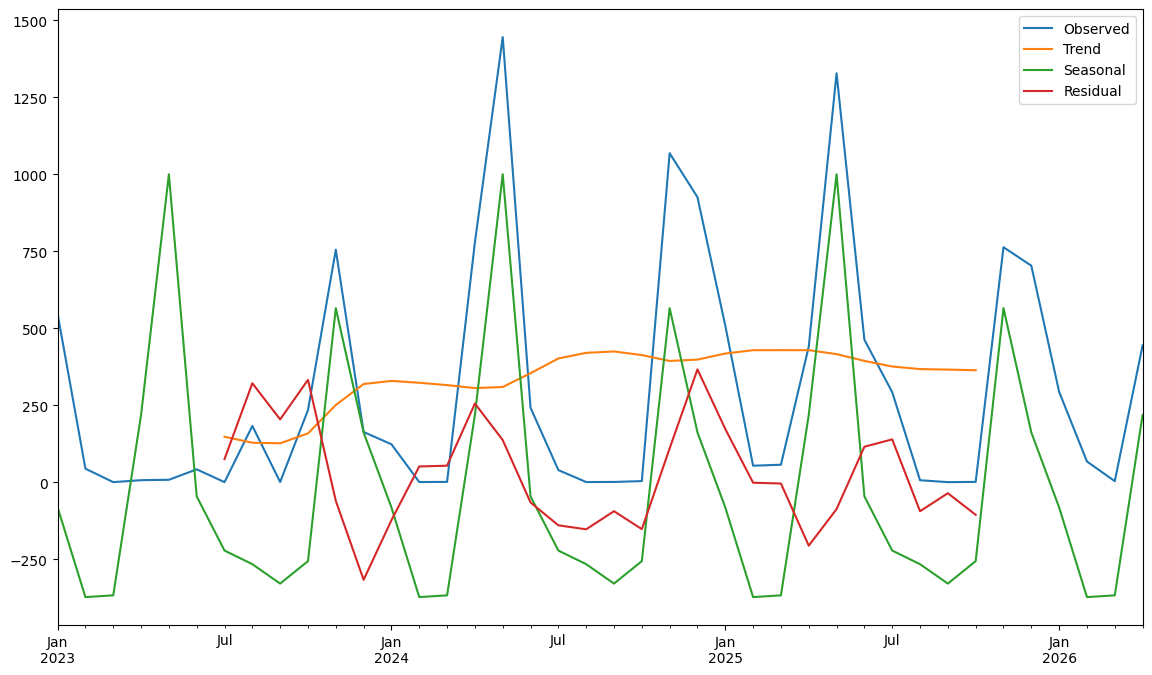

In [22]:
plt.figure(figsize=(14, 8))
result.observed.plot(label="Observed")
result.trend.plot(label="Trend")
result.seasonal.plot(label="Seasonal")
result.resid.plot(label="Residual")
plt.legend()
plt.show()

### **2.2 Empalmes**



```
# Método: factor de enlace
```



🔗 Enlace 1: 1979 → 1994

$$F_1 = \frac{pbi_{1994}^{(1994)}}{pbi_{1994}^{(1979)}}$$

---

🔗 Enlace 2: 1994 → 2007

$$F_2 = \frac{pbi_{2007}^{(2007)}}{pbi_{2007}^{(1994)}}$$

---

🔹 Tramo 1: 1970–1993
$$
pbi_t^{2007} = pbi_t^{(1979)} \cdot F_1 \cdot F_2
$$

🔹 Tramo 2: 1994–2006
$$
pbi_t^{2007} = pbi_t^{(1994)} \cdot F_2
$$

🔹 Tramo 3: 2007–2024
$$
pbi_t^{2007} = pbi_t^{(2007)}
$$

In [23]:
datos4 = pd.read_excel("https://github.com/chavezgranados/Quantitative-Methods/raw/refs/heads/main/datasets/04pbi_junin.xlsx")

In [24]:
pbi=datos4.copy()

In [25]:
pbi.head()

,t,pbi_1979,pbi_1994,pbi_2007
0,1970,129137.0,NaN,NaN
1,1971,127903.0,NaN,NaN
2,1972,135700.0,NaN,NaN
3,1973,145748.0,NaN,NaN
4,1974,146087.0,NaN,NaN


In [26]:
# enlace 1979 -> 1994 (año 1994)
f1 = (pbi.loc[pbi["t"] == 1994, "pbi_1994"].iloc[0] /
    pbi.loc[pbi["t"] == 1994, "pbi_1979"].iloc[0])
# enlace 1994 -> 2007 (año 2007)
f2 = (pbi.loc[pbi["t"] == 2007, "pbi_2007"].iloc[0] /
    pbi.loc[pbi["t"] == 2007, "pbi_1994"].iloc[0])

In [27]:
pbi["pbi_empalmado_2007"] = np.nan

# 1970–1993
mask_79 = (pbi["t"] < 1994) & pbi["pbi_1979"].notna()
pbi.loc[mask_79, "pbi_empalmado_2007"] = pbi["pbi_1979"] * f1 * f2

# 1994–2006
mask_94 = (pbi["t"] >= 1994) & (pbi["t"] < 2007) & pbi["pbi_1994"].notna()
pbi.loc[mask_94, "pbi_empalmado_2007"] = pbi["pbi_1994"] * f2

# 2007–2024
mask_07 = pbi["pbi_2007"].notna()
pbi.loc[mask_07, "pbi_empalmado_2007"] = pbi["pbi_2007"]

In [28]:
pd.set_option('display.float_format', '{:,.0f}'.format)

In [29]:
pbi.head()

,t,pbi_1979,pbi_1994,pbi_2007,pbi_empalmado_2007
0,1970,"129,137",NaN,NaN,"4,083,627"
1,1971,"127,903",NaN,NaN,"4,044,605"
2,1972,"135,700",NaN,NaN,"4,291,166"
3,1973,"145,748",NaN,NaN,"4,608,908"
4,1974,"146,087",NaN,NaN,"4,619,628"


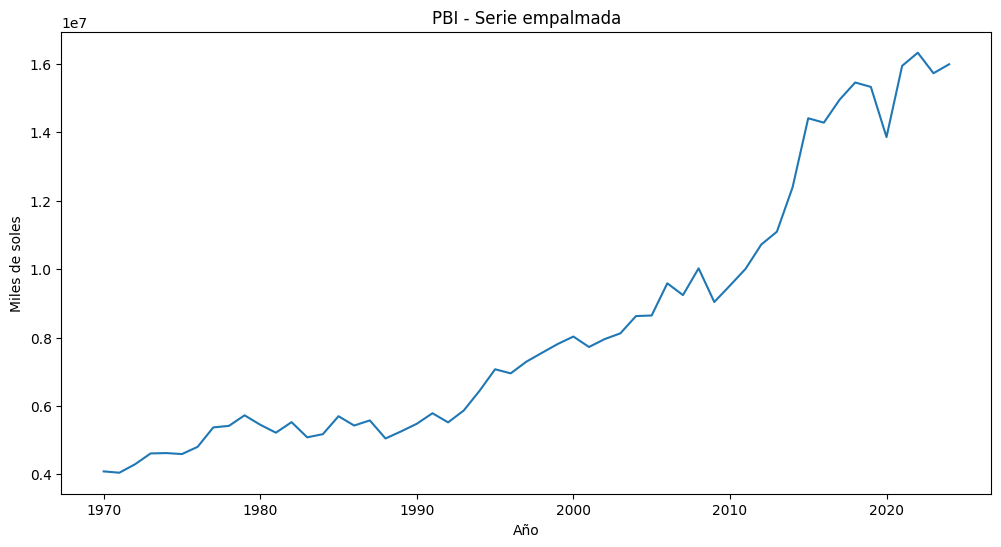

In [30]:
plt.figure(figsize=(12, 6))
plt.plot(pbi["t"], pbi["pbi_empalmado_2007"], label="PBI empalmado (2007=100)")
plt.title("PBI - Serie empalmada")
plt.xlabel("Año")
plt.ylabel("Miles de soles")
plt.show()

### **2.3 Retropolación**

Se toma la serie más reciente (base 2007) como referencia y se reconstruye el pasado utilizando las tasas de crecimiento de las series antiguas.

$$X_{t-1}=\dfrac{X_t}{1+g_t}$$

donde
$$g_t=\dfrac{X_t-X_{t-1}}{X_{t-1}}$$

In [32]:
retro = datos4.copy()

In [33]:
retro["g94"] = retro["pbi_1994"].pct_change(fill_method=None)
retro["g79"] = retro["pbi_1979"].pct_change(fill_method=None)

In [34]:
retro["pbi_retro_2007"] = np.nan

In [35]:
mask = retro["t"] >= 2007
retro.loc[mask, "pbi_retro_2007"] = retro.loc[mask, "pbi_2007"]

In [40]:
for año in range(2006, 1993, -1):
    valor_siguiente = retro.loc[retro["t"] == año + 1,"pbi_retro_2007"].iloc[0]
    g = retro.loc[retro["t"] == año + 1, "g94"].iloc[0]
    retro.loc[retro["t"] == año, "pbi_retro_2007"] = valor_siguiente / (1 + g)

In [41]:
for año in range(1993, 1969, -1):
    valor_siguiente = retro.loc[
        retro["t"] == año + 1, "pbi_retro_2007"].iloc[0]
    g = retro.loc[retro["t"] == año + 1,"g79"].iloc[0]
    retro.loc[retro["t"] == año, "pbi_retro_2007"] = valor_siguiente / (1 + g)

In [42]:
retro.head()

,t,pbi_1979,pbi_1994,pbi_2007,g94,g79,pbi_retro_2007
0,1970,"129,137",NaN,NaN,NaN,NaN,"4,083,627"
1,1971,"127,903",NaN,NaN,NaN,-0,"4,044,605"
2,1972,"135,700",NaN,NaN,NaN,0,"4,291,166"
3,1973,"145,748",NaN,NaN,NaN,0,"4,608,908"
4,1974,"146,087",NaN,NaN,NaN,0,"4,619,628"




```
# Explicar matemáticamente porqué los resultados de empalme y retropolación salen lo mismo.
```

